<a href="https://colab.research.google.com/github/ParasGore/SOC-Stock-Trading-With-LSTM-And-RL/blob/main/Week1/Matplotlib_and_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring AAPL Stock Data with Pandas and Matplotlib

In this assignment, you will use `AAPL.csv` to practice basic data inspection, summary statistics, and plotting with Pandas and Matplotlib.

The dataset contains daily Apple stock price data with the columns `date`, `adj_close`, `close`, `high`, `low`, `open`, `volume`, and `symbol`.

For each exercise, write your code between the `# <START>` and `# <END>` comments.


In [20]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')


## Exercise 1: Load and Inspect the Dataset

Read `AAPL.csv` into a DataFrame named `df`. Then display:

- The first 10 rows
- The shape of the dataset
- The column names
- The data types of each column


In [21]:
# <START>
# Read AAPL.csv into df
url = "https://raw.githubusercontent.com/Abhinav-pro1003/SOC-Stock-Trading-With-LSTM-And-RL/refs/heads/main/Week1/AAPL.csv"
df = pd.read_csv(url)

# Display the first 10 rows
df.head(10)

# Display the shape, columns, and data types
print(df.shape)
print(df.columns)
print(df.dtypes)
# <END>


(2858, 8)
Index(['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume',
       'symbol'],
      dtype='object')
date          object
adj_close    float64
close        float64
high         float64
low          float64
open         float64
volume         int64
symbol        object
dtype: object


## Exercise 2: Convert and Sort Dates

The `date` column is currently read as text. Convert it to a datetime column, sort the rows by date, and reset the index.

After sorting, display the earliest date and latest date in the dataset.


In [32]:
# <START>
# Convert date column to datetime
df.loc[:, 'date'] = pd.to_datetime(df['date'])

# Sort by date and reset the index
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)
# Display the first and last dates
print(df['date'].iloc[0])
print(df['date'].iloc[-1])
# <END>


2015-01-02 00:00:00
2026-05-14 00:00:00


## Exercise 3: Summary Statistics

Find the mean, standard deviation, highest value, and lowest value for these numerical columns:

- `open`
- `high`
- `low`
- `close`
- `adj_close`
- `volume`

Store the result in a variable named `summary_stats` and display it.


In [23]:
numeric_cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']

# <START>
# Calculate mean, standard deviation, minimum, and maximum
summary_stats = df[numeric_cols].agg(['mean', 'std', 'max', 'min'])

# Display summary_stats
print(summary_stats)

# <END>


            open        high         low       close   adj_close        volume
mean  113.560275  114.790064  112.422560  113.659821  111.213828  1.093330e+08
std    77.639929   78.469748   76.889401   77.717700   78.157844  6.794444e+07
max   299.820007  300.920013  295.380005  298.869995  298.869995  6.488252e+08
min    22.500000   22.917500   22.367500   22.584999   20.565870  1.791060e+07


## Exercise 4: Highest and Lowest Adjusted Close

Find the row where Apple had the highest `adj_close` price and the row where it had the lowest `adj_close` price.

Display the `date`, `adj_close`, and `volume` for both rows.


In [24]:
# <START>
# Find the index of the highest and lowest adjusted close values
adj_close_max_idx = df['adj_close'].idxmax()
adj_close_min_idx = df['adj_close'].idxmin()

# Select date, adj_close, and volume for both rows
adj_max = df.loc[adj_close_max_idx, ['date', 'adj_close', 'volume']]
adj_min = df.loc[adj_close_min_idx, ['date', 'adj_close', 'volume']]

# Display the results

print(f'Highest adjusted close: \n{adj_max}')

print(f'Lowest adjusted close: \n{adj_min}')

# <END>


Highest adjusted close: 
date         2026-05-13 00:00:00
adj_close             298.869995
volume                  52684300
Name: 2856, dtype: object
Lowest adjusted close: 
date         2016-05-12 00:00:00
adj_close               20.56587
volume                 305258800
Name: 342, dtype: object


## Exercise 5: Plot Date vs Adjusted Close

Create a line plot showing how `adj_close` changes over time.

Your plot should include:

- Figure size `(12, 5)`
- A blue line
- Title: `AAPL Adjusted Close Price Over Time`
- X-axis label: `Date`
- Y-axis label: `Adjusted Close Price`


/usr/local/lib/python3.12/dist-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


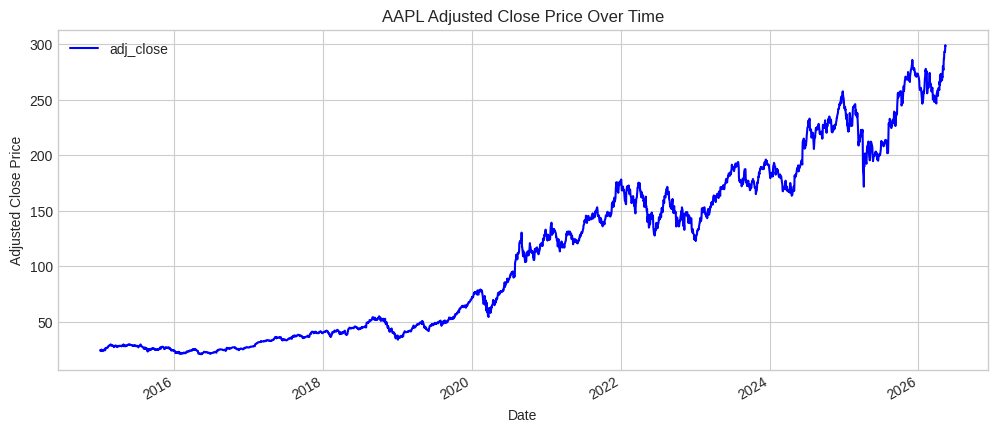

In [25]:
# <START>
df.plot(x='date', y='adj_close', figsize=(12, 5), color='blue')
plt.title('AAPL Adjusted Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.show()
# <END>


## Exercise 6: Plot Trading Volume Over Time

Create a line plot for `volume` over time.

Your plot should include:

- Figure size `(12, 5)`
- A purple line
- Title: `AAPL Trading Volume Over Time`
- X-axis label: `Date`
- Y-axis label: `Volume`


/usr/local/lib/python3.12/dist-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


Text(0, 0.5, 'Volume')

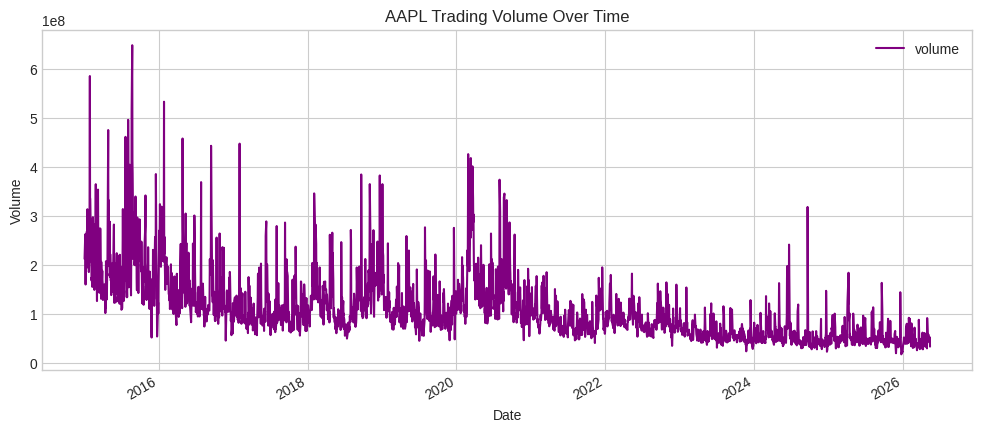

In [26]:
# <START>
df.plot(x='date', y='volume', figsize=(12, 5), color='purple')
plt.title('AAPL Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
# <END>


## Exercise 7: Top 10 Highest Volume Days

Find the 10 days with the highest trading volume and store them in `top_volume_days`.

Then create a bar chart with:

- `date` on the X-axis
- `volume` on the Y-axis
- Title: `Top 10 AAPL Trading Volume Days`
- Rotated X-axis labels so the dates are readable


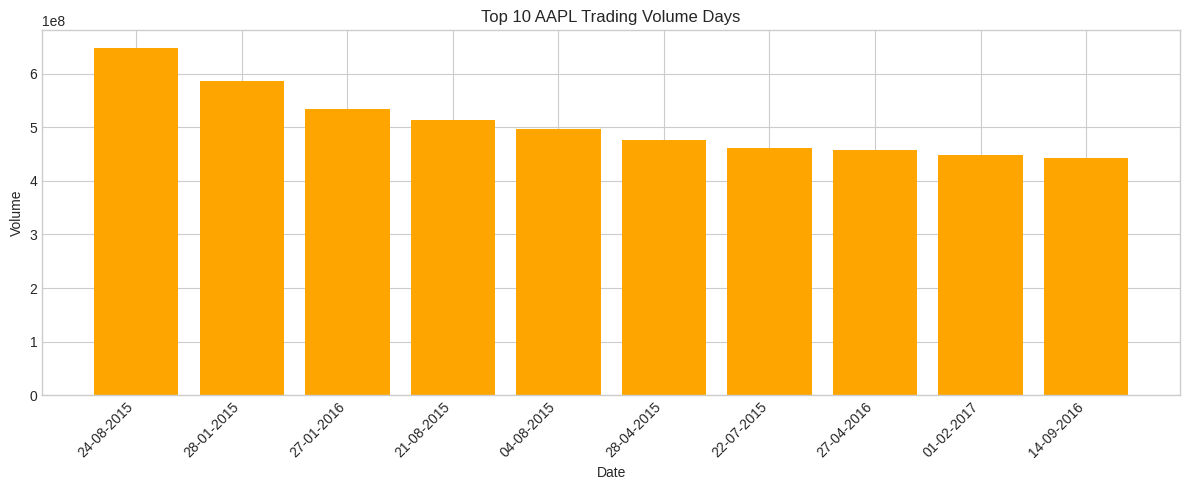

In [27]:
# <START>
# Find the 10 highest volume days
top_volume_days = df.nlargest(10, 'volume')

# Plot the result
plt.figure(figsize=(12, 5))
plt.bar(pd.to_datetime(top_volume_days['date']).dt.strftime('%d-%m-%Y'), top_volume_days['volume'], color='orange')
plt.title('Top 10 AAPL Trading Volume Days')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# <END>

## Exercise 8: Moving Average Plot

Create two new columns:

- `ma_20`: 20-day moving average of `adj_close`
- `ma_50`: 50-day moving average of `adj_close`

Then plot `adj_close`, `ma_20`, and `ma_50` on the same graph.


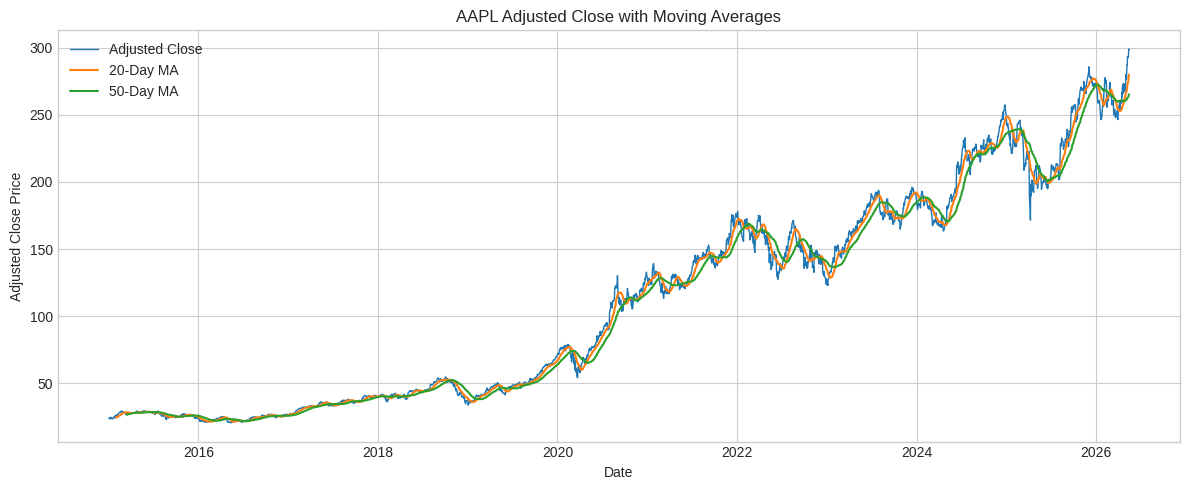

In [28]:
# <START>
# Calculate moving averages
df.loc[:, 'ma_20'] = df['adj_close'].rolling(window=20).mean()
df.loc[:, 'ma_50'] = df['adj_close'].rolling(window=50).mean()
# Plot adjusted close and moving averages
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['adj_close'], label='Adjusted Close', linewidth=1)
plt.plot(df['date'], df['ma_20'], label='20-Day MA', linewidth=1.5)
plt.plot(df['date'], df['ma_50'], label='50-Day MA', linewidth=1.5)
plt.title('AAPL Adjusted Close with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.tight_layout()
plt.show()
# <END>


## Exercise 9: Relationship Between Daily Range and Volume

Create a new column named `daily_range` using:

`daily_range = high - low`

Then make a scatter plot with `daily_range` on the X-axis and `volume` on the Y-axis.


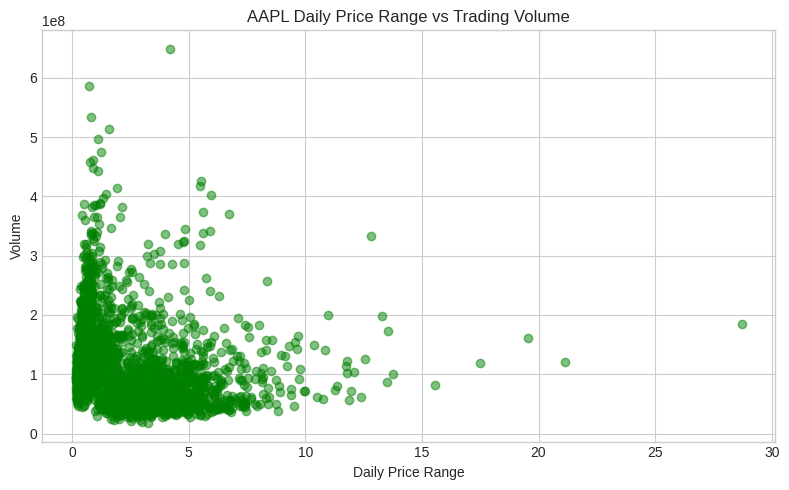

In [29]:
# <START>
# Calculate daily range
df.loc[:,'daily_range'] = df['high'] - df['low']
# Create scatter plot

plt.figure(figsize=(8, 5))
plt.scatter(df['daily_range'], df['volume'], alpha=0.5, color='green')
plt.title('AAPL Daily Price Range vs Trading Volume')
plt.xlabel('Daily Price Range')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()
# <END>


## Bonus Exercise: Monthly Average Adjusted Close

Group the data by month and calculate the average `adj_close` for each month. Plot the monthly averages as a line plot.

Hint: Use `df.set_index('date').resample('ME')`.


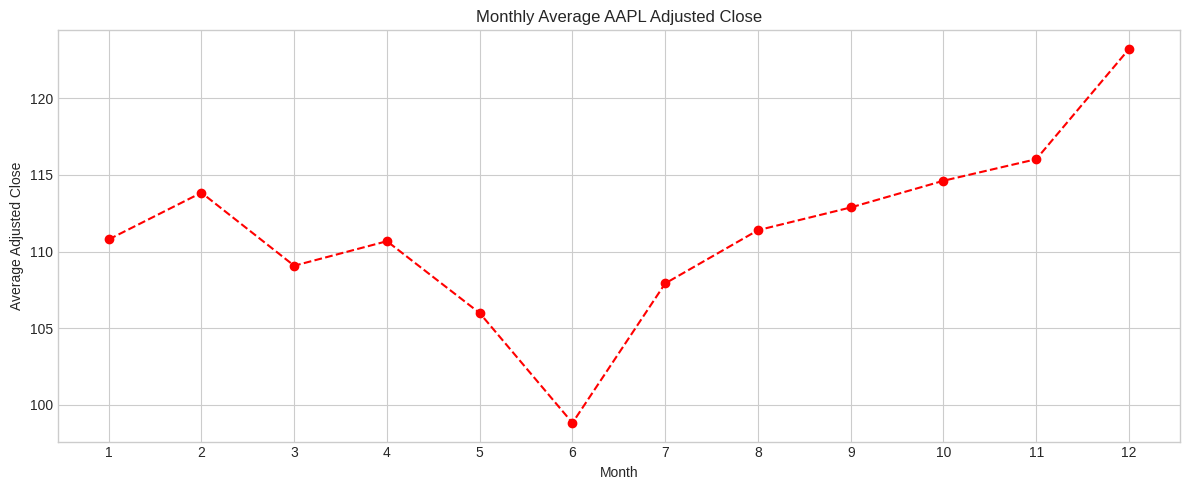

In [51]:
# <START>
# Calculate monthly average adjusted close
df['date'] = pd.to_datetime(df['date'])
df.loc[:, 'month'] = df['date'].dt.month
monthly_avg = df.groupby('month')['adj_close'].mean()
# Plot monthly average adjusted close
plt.figure(figsize=(12, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='--', color='red')
plt.title('Monthly Average AAPL Adjusted Close')
plt.xlabel('Month')
plt.ylabel('Average Adjusted Close')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()
# <END>